# Pricing and Greek Plots

### Libraries

In [1]:
import time
NOTEBOOK_START_TIME = time.time()
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent / 'src'))

In [2]:
from abc import ABC, abstractmethod
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from option import CallOption, PutOption
from underlying import GeometricBrownianMotion

### Initialisation

In [4]:
np.random.seed(1973)
SAVE_FIGS = True

Market parameters:

In [5]:
SPOT = 100 # $100
STRIKE = 100 # $100
MATURITY = 1 # 1 year
RATE = 0.05 # 5%
DRIFT = 0.1 # 10%
VOLATILITY = 0.2 # 20%

Graphing parameters:

In [6]:
MESH_RESOLUTION = 1/1000
RUNS = 5
time_axis = np.linspace(0, MATURITY, int(MATURITY/MESH_RESOLUTION)+1)

In [7]:
low_spot = 1
high_spot = 200
spot_axis = np.linspace(low_spot, high_spot, ((high_spot-low_spot)//low_spot)+1)

In [8]:
low_spot = 75
high_spot = 125
spot_grid = np.linspace(low_spot, high_spot, ((high_spot-low_spot)//1)+1)
spot_grid, time_grid = np.meshgrid(spot_grid, time_axis)

Market objects:

In [9]:
asset = GeometricBrownianMotion(SPOT, DRIFT, VOLATILITY)

call = CallOption(STRIKE, MATURITY)
put = PutOption(STRIKE, MATURITY)

bull_call = CallOption(90,1) - CallOption(110,1)
butterfly = CallOption(75, 1) - 2*CallOption(100, 1) + CallOption(125, 1)
call_condor = CallOption(50,1) - CallOption(60,1) - CallOption(140,1) + CallOption(150,1)
straddle = CallOption(100,1) + PutOption(100,1)
strangle = CallOption(125,1) + PutOption(75,1)

combo_option_1 = strangle
combo_option_2 = butterfly

### Underlying Model

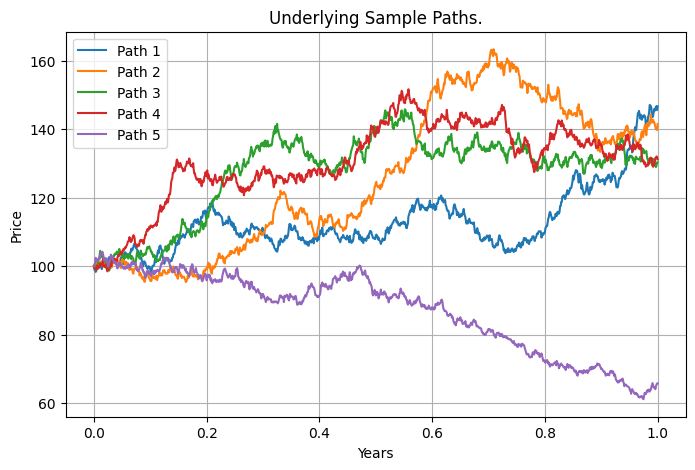

In [10]:
plt.figure(figsize=(8,5))
for j in range(RUNS):
    plt.plot(time_axis, asset.simulate(MATURITY, RUNS, MESH_RESOLUTION)[j], label=f"Path {j+1}")

plt.title(f"Underlying Sample Paths.")
plt.xlabel("Years")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/gbm_samples.png')

### Vanilla Options

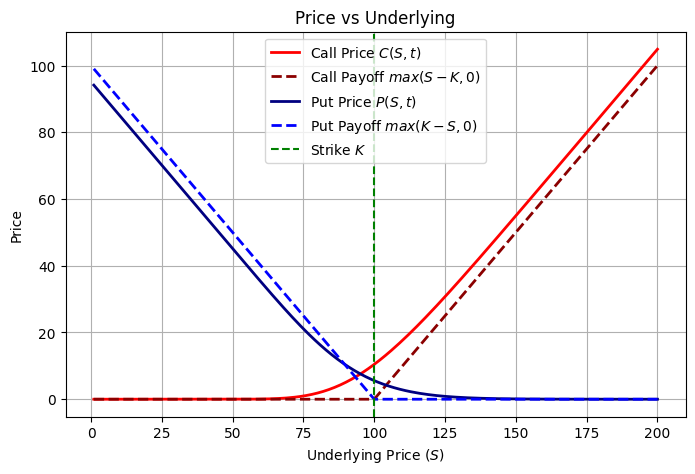

In [11]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.price(spot_axis, 0, RATE, VOLATILITY), color='red', label=r"Call Price $C(S,t)$", linewidth=2)
plt.plot(spot_axis, call.payoff(spot_axis), '--', color='darkred', label=r"Call Payoff $max(S-K,0)$", linewidth=2)
plt.plot(spot_axis, put.price(spot_axis, 0, RATE, VOLATILITY), color='navy', label=r"Put Price $P(S,t)$", linewidth=2)
plt.plot(spot_axis, put.payoff(spot_axis), '--', color='blue', label=r"Put Payoff $max(K-S,0)$", linewidth=2)
plt.axvline(STRIKE, color='green', linestyle='--', label=r"Strike $K$")
plt.xlabel(r"Underlying Price ($S$)")
plt.ylabel("Price")
plt.title("Price vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/put_call.png')

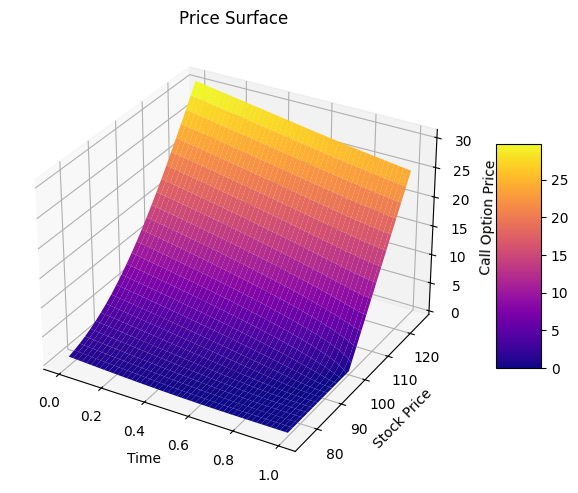

In [12]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(time_grid, spot_grid, call.price(spot_grid, time_grid, RATE, VOLATILITY), cmap='plasma')
ax.set_xlabel("Time")
ax.set_ylabel("Stock Price")
ax.set_zlabel("Call Option Price")
ax.set_title("Price Surface")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig('../figures/callprice_surface.png')

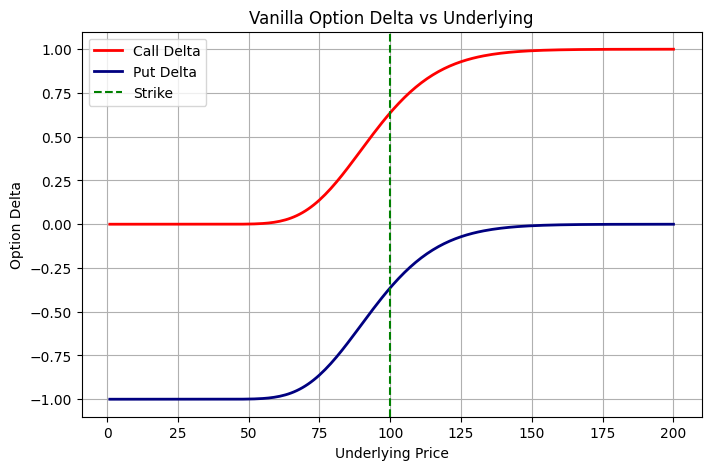

In [13]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.delta(spot_axis, 0, RATE, VOLATILITY), color='red', label="Call Delta", linewidth=2)
plt.plot(spot_axis, put.delta(spot_axis, 0, RATE, VOLATILITY), color='navy', label="Put Delta", linewidth=2)
plt.axvline(STRIKE, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Delta")
plt.title("Vanilla Option Delta vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/put_call_delta_parity.png')

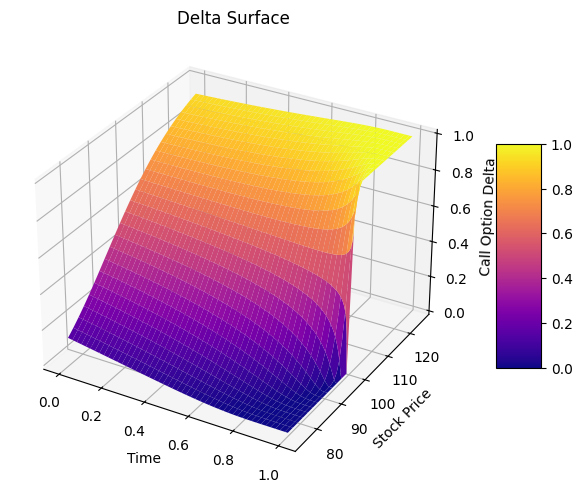

In [14]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(time_grid, spot_grid, call.delta(spot_grid, time_grid, RATE, VOLATILITY), cmap='plasma')
ax.set_xlabel("Time")
ax.set_ylabel("Stock Price")
ax.set_zlabel("Call Option Delta")
ax.set_title("Delta Surface")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig('../figures/calldelta_surface.png')

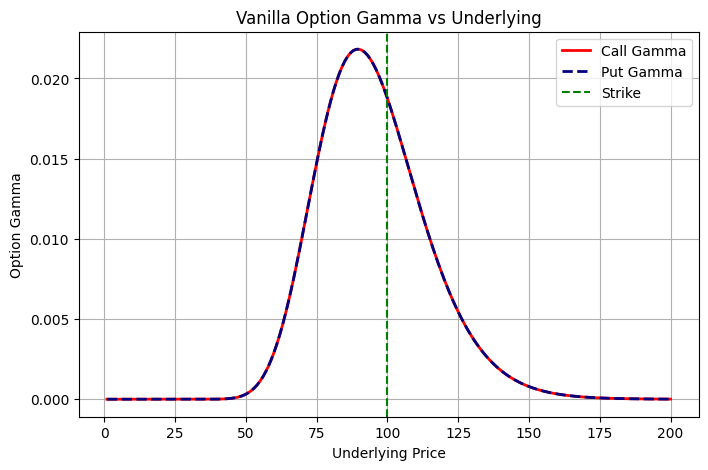

In [15]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.gamma(spot_axis, 0, RATE, VOLATILITY), color='red', label="Call Gamma", linewidth=2)
plt.plot(spot_axis, put.gamma(spot_axis, 0, RATE, VOLATILITY), '--', color='navy', label="Put Gamma", linewidth=2)
plt.axvline(STRIKE, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Gamma")
plt.title("Vanilla Option Gamma vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/put_call_gamma.png')

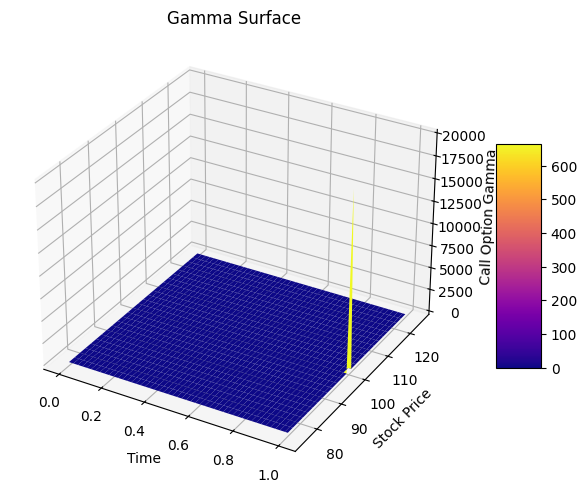

In [16]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(time_grid, spot_grid, call.gamma(spot_grid, time_grid, RATE, VOLATILITY), cmap='plasma')
ax.set_xlabel("Time")
ax.set_ylabel("Stock Price")
ax.set_zlabel("Call Option Gamma")
ax.set_title("Gamma Surface")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig('../figures/callgamma_surface.png')

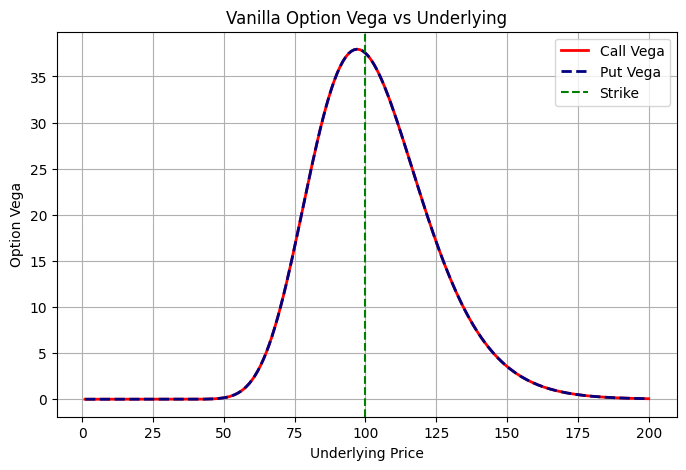

In [17]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.vega(spot_axis, 0, RATE, VOLATILITY), color='red', label="Call Vega", linewidth=2)
plt.plot(spot_axis, put.vega(spot_axis, 0, RATE, VOLATILITY), '--', color='navy', label="Put Vega", linewidth=2)
plt.axvline(STRIKE, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Vega")
plt.title("Vanilla Option Vega vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/put_call_vega.png')

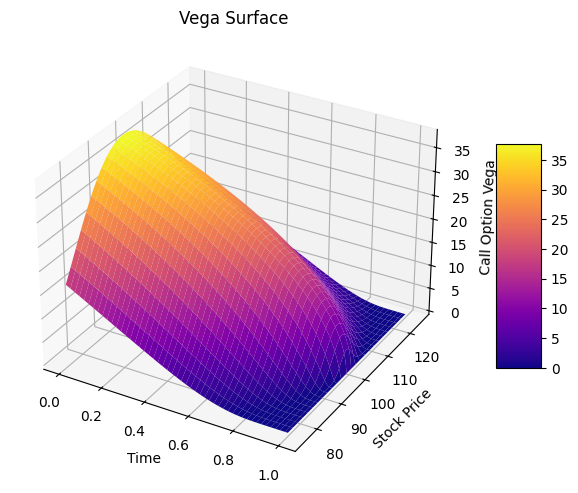

In [18]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(time_grid, spot_grid, call.vega(spot_grid, time_grid, RATE, VOLATILITY), cmap='plasma')
ax.set_xlabel("Time")
ax.set_ylabel("Stock Price")
ax.set_zlabel("Call Option Vega")
ax.set_title("Vega Surface")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig('../figures/callvega_surface.png')

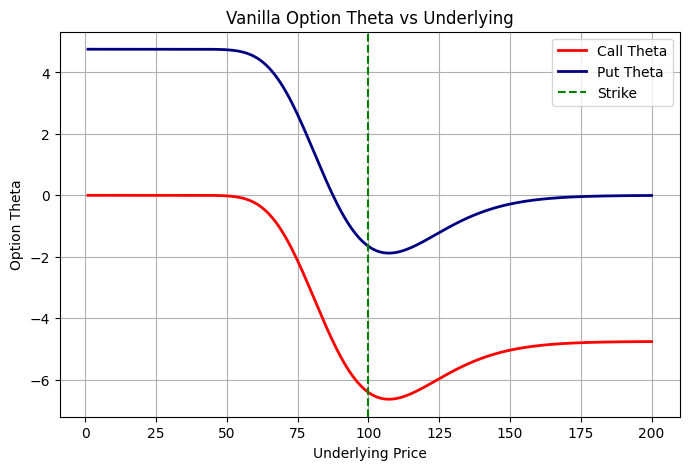

In [19]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, call.theta(spot_axis, 0, RATE, VOLATILITY), color='red', label="Call Theta", linewidth=2)
plt.plot(spot_axis, put.theta(spot_axis, 0, RATE, VOLATILITY), color='navy', label="Put Theta", linewidth=2)
plt.axvline(STRIKE, color='green', linestyle='--', label="Strike")
plt.xlabel("Underlying Price")
plt.ylabel("Option Theta")
plt.title("Vanilla Option Theta vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/put_call_theta.png')

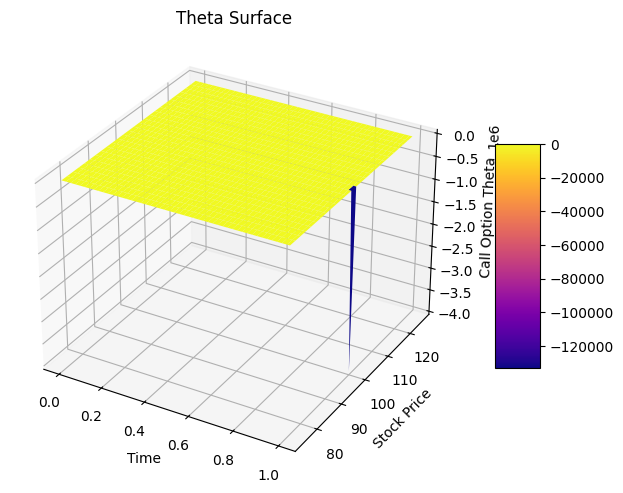

In [20]:
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(time_grid, spot_grid, call.theta(spot_grid, time_grid, RATE, VOLATILITY), cmap='plasma')
ax.set_xlabel("Time")
ax.set_ylabel("Stock Price")
ax.set_zlabel("Call Option Theta")
ax.set_title("Theta Surface")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.tight_layout()
if SAVE_FIGS:
    plt.savefig('../figures/calltheta_surface.png')

### Option Spreads

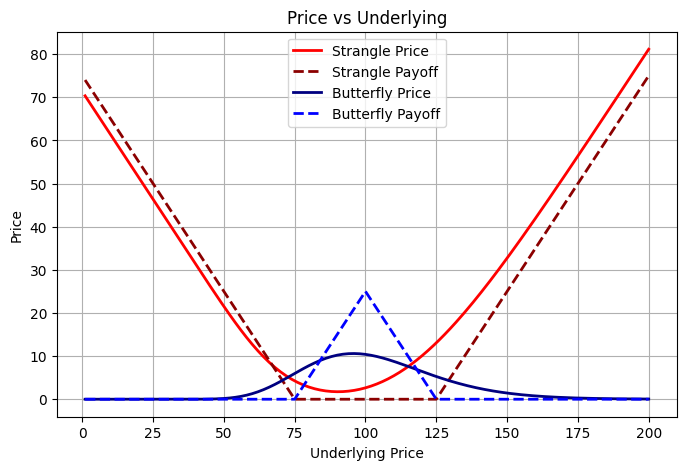

In [21]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.price(spot_axis, 0, RATE, VOLATILITY), color='red', label="Strangle Price", linewidth=2)
plt.plot(spot_axis, combo_option_1.payoff(spot_axis), '--', color='darkred', label="Strangle Payoff", linewidth=2)
plt.plot(spot_axis, combo_option_2.price(spot_axis, 0, RATE, VOLATILITY), color='navy', label="Butterfly Price", linewidth=2)
plt.plot(spot_axis, combo_option_2.payoff(spot_axis), '--', color='blue', label="Butterfly Payoff", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Price")
plt.title("Price vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/linear_options.png')

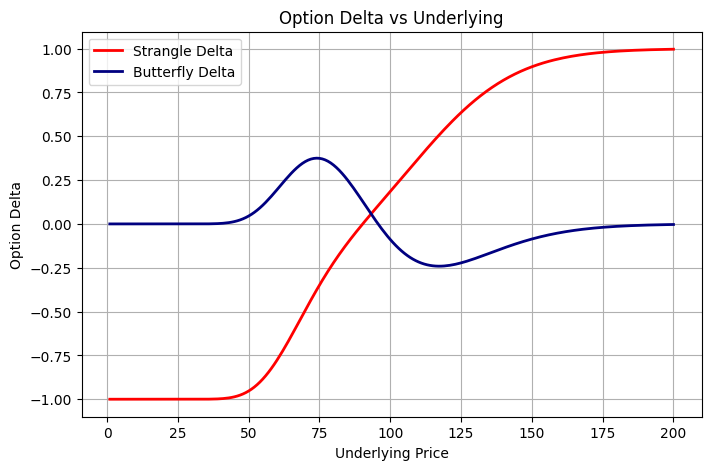

In [22]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.delta(spot_axis, 0, RATE, VOLATILITY), color='red', label="Strangle Delta", linewidth=2)
plt.plot(spot_axis, combo_option_2.delta(spot_axis, 0, RATE, VOLATILITY), color='navy', label="Butterfly Delta", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Delta")
plt.title("Option Delta vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/linear_option_deltas.png')

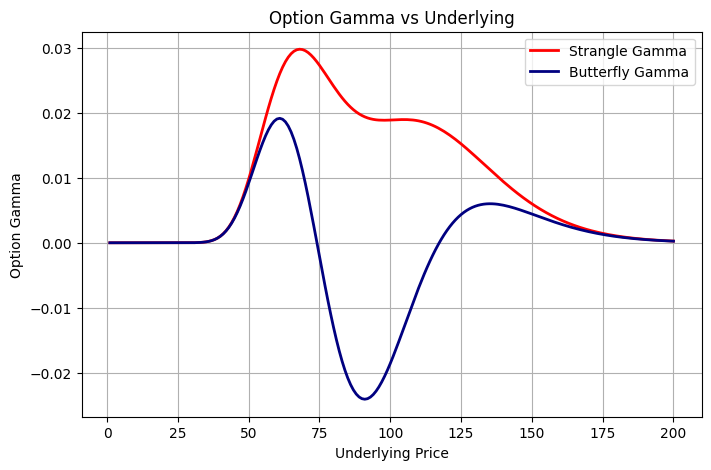

In [23]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.gamma(spot_axis, 0, RATE, VOLATILITY), color='red', label="Strangle Gamma", linewidth=2)
plt.plot(spot_axis, combo_option_2.gamma(spot_axis, 0, RATE, VOLATILITY), color='navy', label="Butterfly Gamma", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Gamma")
plt.title("Option Gamma vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/linear_option_gammas.png')

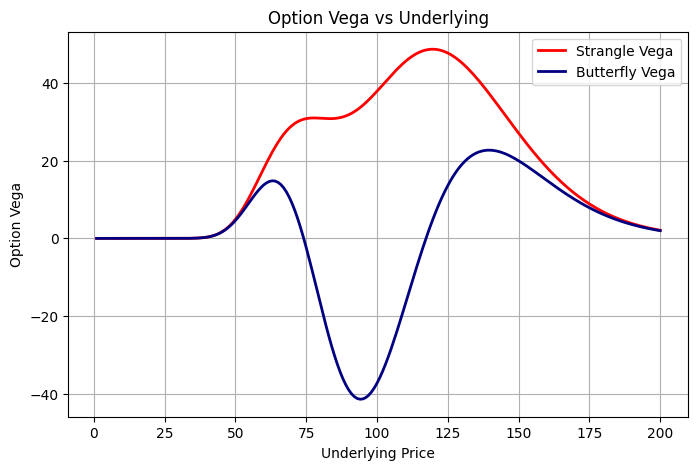

In [24]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.vega(spot_axis, 0, RATE, VOLATILITY), color='red', label="Strangle Vega", linewidth=2)
plt.plot(spot_axis, combo_option_2.vega(spot_axis, 0, RATE, VOLATILITY), color='navy', label="Butterfly Vega", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Vega")
plt.title("Option Vega vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/linear_option_vegas.png')

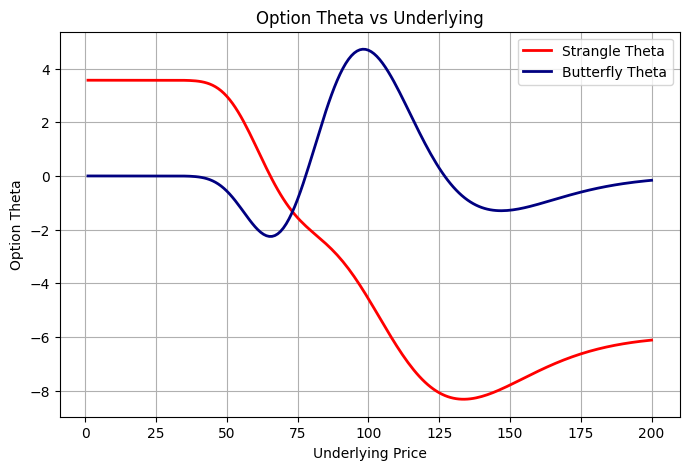

In [25]:
plt.figure(figsize=(8,5))
plt.plot(spot_axis, combo_option_1.theta(spot_axis, 0, RATE, VOLATILITY), color='red', label="Strangle Theta", linewidth=2)
plt.plot(spot_axis, combo_option_2.theta(spot_axis, 0, RATE, VOLATILITY), color='navy', label="Butterfly Theta", linewidth=2)
plt.xlabel("Underlying Price")
plt.ylabel("Option Theta")
plt.title("Option Theta vs Underlying")
plt.legend()
plt.grid(True)
if SAVE_FIGS:
    plt.savefig('../figures/linear_option_thetas.png')

In [26]:
NOTEBOOK_END_TIME = time.time()
ELAPSED_TIME = NOTEBOOK_END_TIME - NOTEBOOK_START_TIME
print(f"Notebook took {ELAPSED_TIME:.3f} seconds to run!")

Notebook took 19.944 seconds to run!
